# 03b - Google Gauge Selection

Identifies which Google flood forecast gauges are relevant to the Niger-Benue system.
Applies two inclusion criteria:
1. **Named-river filter** — gauges with a known river name matching Niger, Benue, or Sokoto (including French spellings for Cameroon).
2. **Benue proximity filter** — quality-verified gauges with an empty river name that fall within 15 km of the Benue river (captures unlabelled upstream gauges in Cameroon).

Also saves a buffered HydroBASINS clip to Azure that extends beyond Nigeria's borders to cover upstream countries (required for the upstream traversal in notebook 04).

**Outputs saved to Azure:**
- `ds-aa-nga-flooding/processed/google_gauges_sel.parquet` — Selected gauges with metadata and geometry
- `ds-aa-nga-flooding/processed/hydrosheds/hybas_af_lev12_v1c_upstream.parquet` — HydroBASINS level 12, clipped to upstream catchment bbox (covers Niger headwaters in Guinea/Mali and Benue headwaters in Cameroon)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import io
import tempfile
import zipfile

import geopandas as gpd
import pandas as pd
import ocha_stratus as stratus
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from src.datasources import grrr, nihsa

load_dotenv()

True

In [3]:
gdf_hydrological_areas = nihsa.load_hydological_areas().set_crs(epsg=4326)

# Buffer HA by 200km to capture upstream gauges outside Nigeria (e.g. Benue headwaters in Cameroon)
gdf_ha_buffered = gpd.GeoDataFrame(
    geometry=[
        gdf_hydrological_areas
        .to_crs(epsg=26392)
        .buffer(200_000)
        .to_crs(epsg=4326)
        .union_all()
    ],
    crs="EPSG:4326"
)

gdf_gauges = grrr.get_gauges_by_area(
    gdf_ha_buffered,
    include_non_quality_verified=True
)

print(f"Total gauges in search area: {len(gdf_gauges)}")
print(f"  Quality-verified: {gdf_gauges.quality_verified.sum()}")

Total gauges in search area: 3982
  Quality-verified: 56


In [4]:
# Diagnostic: inspect river names for gauges outside Nigeria
# to catch alternate spellings and unlabelled gauges in upstream countries
nigeria_bbox_lon = (2.5, 15.0)
nigeria_bbox_lat = (3.0, 14.5)
gauges_outside_nigeria = gdf_gauges[
    ~(
        gdf_gauges.longitude.between(*nigeria_bbox_lon) &
        gdf_gauges.latitude.between(*nigeria_bbox_lat)
    )
]
print(f"Gauges outside Nigeria bbox: {len(gauges_outside_nigeria)}")
print("\nRiver names:")
print(gauges_outside_nigeria["river"].value_counts(dropna=False).to_string())

Gauges outside Nigeria bbox: 176

River names:
river
          175
Logone      1


In [5]:
# --- Filter 1: named-river gauges ---
gdf_gauges_sel = gdf_gauges[
    gdf_gauges.river.isin(["Niger", "Benue", "Bénoué", "Benoue", "Sokoto"])
].copy()
print(f"Named-river gauges: {len(gdf_gauges_sel)}")

# --- Filter 2: quality-verified unlabelled gauges near the Benue (Cameroon) ---
# Download HydroRIVERS GDB once — bbox covers both the Benue proximity filter
# area (east to 16°E) and the full Nigeria visualization area (west to 2.5°E).
gdf_empty_river_qv = gdf_gauges[
    (gdf_gauges.river.fillna("").str.strip() == "") & gdf_gauges.quality_verified
].copy()

combined_bbox = (2.5, 3, 16.0, 14.5)
blob_data = stratus.load_blob_data("ds-aa-nga-flooding/raw/hydrosheds/HydroRIVERS_v10_af.gdb.zip")
with tempfile.TemporaryDirectory() as tmpdir:
    with zipfile.ZipFile(io.BytesIO(blob_data), "r") as zip_ref:
        zip_ref.extractall(tmpdir)
    gdf_rivers_raw = gpd.read_file(
        f"{tmpdir}/HydroRIVERS_v10_af.gdb",
        layer="HydroRIVERS_v10_af",
        bbox=combined_bbox,
    )

if len(gdf_empty_river_qv) > 0:
    # Project to compute centroids accurately before filtering
    centroids = gdf_rivers_raw.to_crs(epsg=32633).geometry.centroid.to_crs(epsg=4326)
    gdf_benue = gdf_rivers_raw[
        (gdf_rivers_raw["MAIN_RIV"] == 10877687) &
        (centroids.y < 10)
    ]
    benue_buffer = (
        gdf_benue
        .to_crs(epsg=32633)
        .buffer(15_000)
        .to_crs(epsg=4326)
        .union_all()
    )
    gdf_benue_unlabelled = gdf_empty_river_qv[
        gdf_empty_river_qv.geometry.within(benue_buffer)
    ].copy()
    print(f"Unlabelled quality-verified gauges near Benue: {len(gdf_benue_unlabelled)}")
    gdf_gauges_sel = pd.concat([gdf_gauges_sel, gdf_benue_unlabelled], ignore_index=True)

print(f"\nTotal selected gauges: {len(gdf_gauges_sel)}")
print(f"  Quality-verified: {gdf_gauges_sel.quality_verified.sum()}")

# Rivers for plotting — ORD_FLOW <= 5 filter (major rivers, same as web map)
gdf_rivers = gdf_rivers_raw[
    (gdf_rivers_raw["MAIN_RIV"] == 10877687) &
    (gdf_rivers_raw["ORD_FLOW"] <= 5)
][["HYRIV_ID", "ORD_FLOW", "DIS_AV_CMS", "geometry"]].copy()
gdf_rivers["geometry"] = gdf_rivers.geometry.simplify(0.001)
print(f"\nRiver segments for plot (ORD_FLOW ≤ 5): {len(gdf_rivers)}")

Named-river gauges: 268
Unlabelled quality-verified gauges near Benue: 5

Total selected gauges: 273
  Quality-verified: 31

River segments for plot (ORD_FLOW ≤ 5): 5265


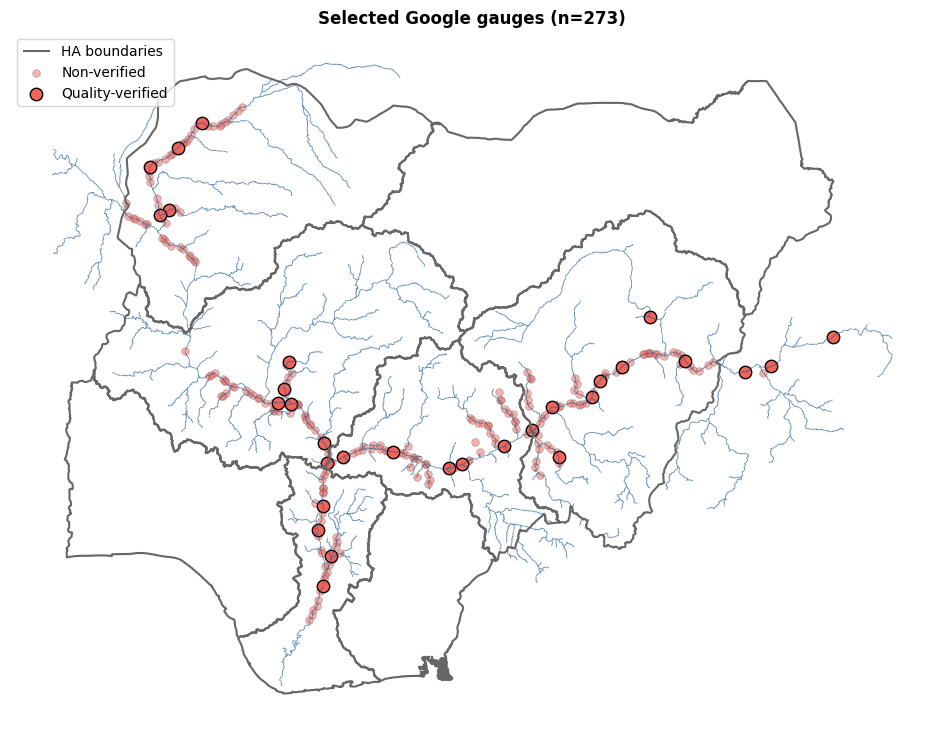

In [12]:
fig, ax = plt.subplots(figsize=(12, 9))

gdf_rivers.plot(ax=ax, color="#1E5A8E", linewidth=0.6, alpha=0.7)
gdf_hydrological_areas.boundary.plot(ax=ax, color="#666666", linewidth=1.5, label="HA boundaries")
gdf_gauges_sel[~gdf_gauges_sel.quality_verified].plot(
    ax=ax, color="#F2645A", markersize=30, alpha=0.5,
    edgecolor="#666666", linewidth=0.5, label="Non-verified"
)
gdf_gauges_sel[gdf_gauges_sel.quality_verified].plot(
    ax=ax, color="#F2645A", markersize=80, edgecolor="black", linewidth=1,
    label="Quality-verified"
)
ax.legend(loc="upper left")
ax.set_title(f"Selected Google gauges (n={len(gdf_gauges_sel)})", fontweight="bold")
ax.set_axis_off()
plt.savefig("figures/selected_gauges.png", bbox_inches="tight", dpi=300)

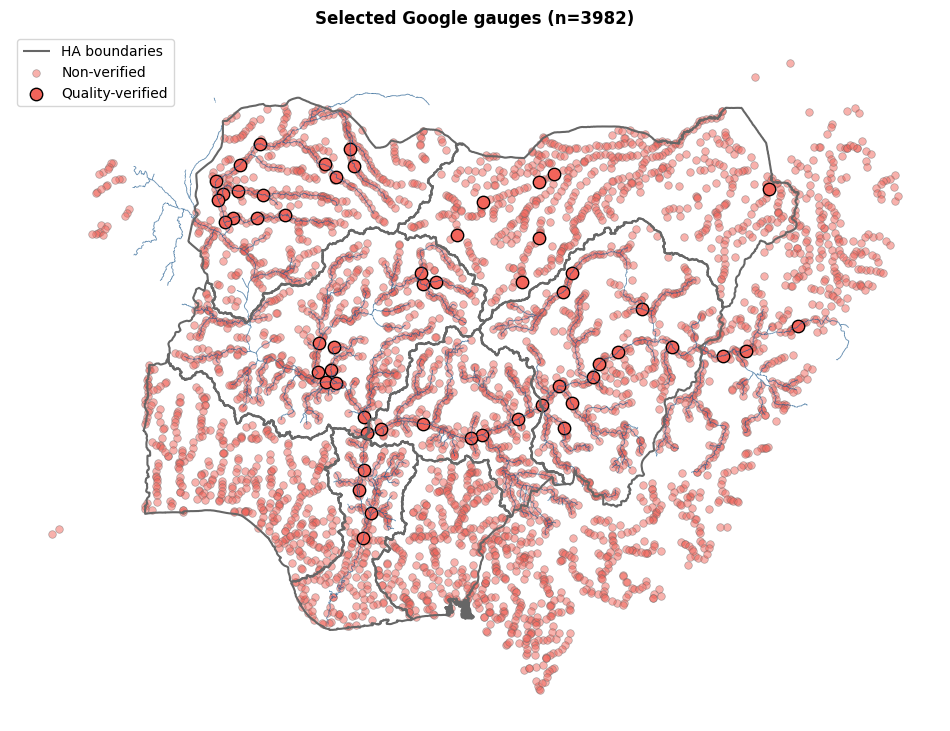

In [11]:
fig, ax = plt.subplots(figsize=(12, 9))

gdf_rivers.plot(ax=ax, color="#1E5A8E", linewidth=0.6, alpha=0.7)
gdf_hydrological_areas.boundary.plot(ax=ax, color="#666666", linewidth=1.5, label="HA boundaries")
gdf_gauges[~gdf_gauges.quality_verified].plot(
    ax=ax, color="#F2645A", markersize=30, alpha=0.5,
    edgecolor="#666666", linewidth=0.5, label="Non-verified"
)
gdf_gauges[gdf_gauges.quality_verified].plot(
    ax=ax, color="#F2645A", markersize=80, edgecolor="black", linewidth=1,
    label="Quality-verified"
)
ax.legend(loc="upper left")
ax.set_title(f"Selected Google gauges (n={len(gdf_gauges)})", fontweight="bold")
ax.set_axis_off()
plt.savefig("figures/all_gauges.png", bbox_inches="tight", dpi=300)

In [8]:
gdf_gauges_sel.head()

,gauge_id,latitude,longitude,site_name,river,source,country_code,quality_verified,has_model,geometry
0,hybas_1120686050,13.310417,5.439583,,Sokoto,HYBAS,None,False,True,POINT (5.43958 13.31042)
1,hybas_1120690950,13.185417,5.302083,,Sokoto,HYBAS,None,False,True,POINT (5.30208 13.18542)
2,hybas_1120694020,13.106250,5.227083,,Sokoto,HYBAS,None,False,True,POINT (5.22708 13.10625)
3,hybas_1120696100,13.064583,4.814583,,Sokoto,HYBAS,None,True,True,POINT (4.81458 13.06458)
4,hybas_1120696710,13.052083,5.110417,,Sokoto,HYBAS,None,False,True,POINT (5.11042 13.05208)


In [9]:
stratus.upload_parquet_to_blob(gdf_gauges_sel, "ds-aa-nga-flooding/processed/google_gauges_sel.parquet")

## HydroBASINS — buffered clip for upstream analysis

The Azure blob used by `hydrosheds.load_basins(level=12)` was clipped to Nigeria's administrative boundary, which causes Cameroon gauges near the eastern border to miss basin assignments. Here we read the full-Africa shapefile locally and upload a wider clip covering the entire upstream catchment area. 

Only need to run this once to save the data appropriately. 

In [10]:
# from pathlib import Path

# # Covers Niger headwaters (Guinea/Mali) west to ~-15E and Benue headwaters
# # (Cameroon) east to ~16E — wider than the Nigeria-only blob
# upstream_bbox = (-15, 3, 16, 16)

# hybas_shp = Path("data/hybas_af_lev01-12_v1c/hybas_af_lev12_v1c.shp")
# gdf_hybas_upstream = gpd.read_file(hybas_shp, bbox=upstream_bbox).set_crs(epsg=4326)

# print(f"Basins loaded: {len(gdf_hybas_upstream)}")
# print(f"Extent: {gdf_hybas_upstream.total_bounds}")

# stratus.upload_parquet_to_blob(
#     gdf_hybas_upstream,
#     "ds-aa-nga-flooding/processed/hydrosheds/hybas_af_lev12_v1c_upstream.parquet"
# )